In [8]:
import sys
import os
import glob

# Dynamically add all subdirectories with .py files to sys.path
project_root = os.getcwd()
for dirpath, dirnames, filenames in os.walk(project_root):
    if any(fname.endswith('.py') for fname in filenames):
        if dirpath not in sys.path:
            sys.path.append(dirpath)

In [114]:
import data_loader
import dataset_cleaner
import data_splitter
import custom_dataset
import transform_utils
import config
import dataloader_setup
import class_weights
import model_setup
import training
import evaluation
import config_dinov2

# If you need to reload modules after making changes
import importlib
importlib.reload(data_loader)
importlib.reload(dataset_cleaner)
importlib.reload(data_splitter)
importlib.reload(custom_dataset)
importlib.reload(transform_utils)
importlib.reload(config)
importlib.reload(config_dinov2)
importlib.reload(dataloader_setup)
importlib.reload(class_weights)
importlib.reload(model_setup)
importlib.reload(training)
importlib.reload(evaluation)

<module 'evaluation' from '/root/dino_cnn/thesis_codes/evaluation.py'>

In [100]:
# Check what functions are available in data_splitter
print("Available functions in data_splitter:")
print([func for func in dir(data_splitter) if not func.startswith('_')])

Available functions in data_splitter:
['Counter', 'apply_few_shot', 'logger', 'logging', 'np', 'os', 'pickle', 'split_clean_dataset', 'split_clean_dataset_with_config', 'train_test_split']


In [101]:
train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = data_splitter.split_clean_dataset(
    pickle_path='/root/clean_dataset.pkl',
    base_data_dir='/root/crop_pest_data',
    few_shot_mode=None, # None = no few-shot learning, 'percentage' = use percentage of data, 'per_class' = use fixed number of samples per class
    few_shot_value=0.1 # 0.1 = 10%, 0.01 = 1%
)

📂 Loading clean dataset...
📋 Loaded legacy format dataset
🔗 Converting old absolute paths to new base: /root/crop_pest_data
📁 Processing 25,126 clean images
📊 Target split: Train 70.0%, Val 15.0%, Test 15.0%

📊 DATA SPLIT SUMMARY
🖼️  Total images: 25,126
🏷️  Total labels: 25,126 (All images have labels at this stage)
Training:   17,588 (70.0%)
Validation: 3,769 (15.0%)
Test:       3,769 (15.0%)

📋 Class distribution verification:
Total classes: 22
Train classes: 22
Val classes:   22
Test classes:  22
✅ All classes present in all splits!

📈 Per-class split verification (first 5 classes):
  Cashew anthracnose:
    Train: 1,211 (70.0%)
    Val:   259 (15.0%)
    Test:  259 (15.0%)
  Cashew gumosis:
    Train: 274 (69.9%)
    Val:   59 (15.1%)
    Test:  59 (15.1%)
  Cashew healthy:
    Train: 958 (70.0%)
    Val:   205 (15.0%)
    Test:  205 (15.0%)
  Cashew leaf miner:
    Train: 964 (70.0%)
    Val:   207 (15.0%)
    Test:  207 (15.0%)
  Cashew red rust:
    Train: 1,178 (70.0%)
    Val

In [110]:
use_dino = False  # Change to True for DINOv2, False for CNN

if use_dino:
    active_config = config_dinov2
    print(f"🦖 Using DINOv2 model: {active_config.MODEL_NAME}")
else:
    active_config = config
    print(f"🤖 Using CNN model: {active_config.MODEL_NAME}")

🤖 Using CNN model: efficientnet_b3


In [103]:
# Add this cell after your data loading to ACTUALLY limit dataset size
from torch.utils.data import Subset
import numpy as np
# Remove this line: import dataloader

# ACTUALLY limit to 10 total samples
train_indices = np.random.choice(len(train_loader.dataset), size=10, replace=False)
val_indices = np.random.choice(len(val_loader.dataset), size=5, replace=False)  
test_indices = np.random.choice(len(test_loader.dataset), size=5, replace=False)

# Create tiny subsets
train_subset = Subset(train_loader.dataset, train_indices)
val_subset = Subset(val_loader.dataset, val_indices)
test_subset = Subset(test_loader.dataset, test_indices)

# Replace your data loaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_subset, batch_size=min(10, active_config.BATCH_SIZE), shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=min(5, active_config.BATCH_SIZE), shuffle=False, num_workers=0)
test_loader = DataLoader(test_subset, batch_size=min(5, active_config.BATCH_SIZE), shuffle=False, num_workers=0)

print(f"🔬 ACTUALLY limited dataset:")
print(f"   Training: {len(train_subset)} samples")
print(f"   Validation: {len(val_subset)} samples") 
print(f"   Test: {len(test_subset)} samples")

🔬 ACTUALLY limited dataset:
   Training: 10 samples
   Validation: 5 samples
   Test: 5 samples


In [87]:
# =============================================================================
# STEP 3: Create dataloaders (same as before)
# =============================================================================

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = dataloader_setup.create_dataloaders(
    train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, 
    config_module=active_config,  # Pass the active config (DINO or CNN)
    test_keep_original_size=False,
    run_batch_test=False  # Set to True if you want to test batch loading
)

print(f"✅ Data preparation complete!")
print(f"📊 Training samples: {len(train_dataset):,}")
print(f"📊 Validation samples: {len(val_dataset):,}")
print(f"📊 Test samples: {len(test_dataset):,}")
print(f"🏷️ Number of classes: {len(train_dataset.classes)}")


🔧 Creating enhanced training transforms:
  ✅ Resize: (224, 224)
  ✅ Random Rotation: ±10°
  ✅ Random Affine: translate=(0.1, 0.1), scale=(0.9, 1.1)
  ✅ Random Horizontal Flip: enabled
  ✅ Random Vertical Flip: 20.0% chance
  ✅ Color Jitter: brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
  ✅ ToTensor: convert to tensor
  ✅ Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
📊 Total training transforms: 8
🎯 Enhanced for crop pest detection with aggressive augmentation!

🔧 Creating validation transforms:
  ✅ Resize: (224, 224)
  ✅ ToTensor: convert to tensor
  ✅ Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
📊 Total validation transforms: 3

🔧 Creating test transforms:
  ✅ Using validation transforms for test set (resize enabled)

🔧 Creating validation transforms:
  ✅ Resize: (224, 224)
  ✅ ToTensor: convert to tensor
  ✅ Normalize: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
📊 Total validation transforms: 3

=== DATASET SUMMARY ===
Trainin

In [88]:
print(f"🏷️  Model identifier: {model_setup.get_model_identifier(config=active_config)}")
print(f"📐 Image size: {active_config.IMAGE_SIZE}")
print(f"📊 Batch size: {active_config.BATCH_SIZE}")
print(f"⚙️  Optimizer: {active_config.OPTIMIZER}")
print(f"📅 Scheduler: {active_config.SCHEDULER}")

class_weights_tensor = class_weights.calculate_class_weights(train_labels, train_dataset.classes)


🏷️  Model identifier: dino_vitb14
📐 Image size: (224, 224)
📊 Batch size: 32
⚙️  Optimizer: adamw
📅 Scheduler: cosine
⚖️  Calculating class weights for balanced training...
✅ Class weights calculated:
  Cashew anthracnose: 0.660
  Cashew gumosis: 2.918
  Cashew healthy: 0.835
  Cashew leaf miner: 0.829
  Cashew red rust: 0.679
  Cassava bacterial blight: 0.437
  Cassava brown spot: 0.771
  Cassava green mite: 1.124
  Cassava healthy: 0.957
  Cassava mosaic: 0.948
  Maize fall armyworm: 4.017
  Maize grasshoper: 1.697
  Maize healthy: 5.591
  Maize leaf beetle: 1.224
  Maize leaf blight: 1.154
  Maize leaf spot: 0.922
  Maize streak virus: 1.184
  Tomato healthy: 2.452
  Tomato leaf blight: 0.886
  Tomato leaf curl: 2.239
  Tomato septoria leaf spot: 0.416
  Tomato verticulium wilt: 1.480
📊 Class weights tensor shape: torch.Size([22])


In [89]:
# =============================================================================
# STEP 5: Create model and setup training
# =============================================================================


# Create model using the selected config
model = model_setup.create_model(
    num_classes=len(train_dataset.classes), 
    config=active_config  # Uses MODEL_NAME from active_config automatically
)

# Setup training components
model, criterion, optimizer, scheduler, device = model_setup.setup_training(
    model, 
    class_weights_tensor, 
    config=active_config
)


🤖 Creating dinov2_vitb14 model...
🏷️  Model identifier: dino_vitb14
🦖 Loading DINOv2 model: dinov2_vitb14
📋 Using model-specific config for dinov2_vitb14
   LR: 0.0001
   Batch: 32
   Dropout: 0.1


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


📐 DINOv2 embedding dimension: 768
🧊 Backbone frozen (will unfreeze later if specified)
⚠️  Gradient checkpointing not supported by this model
🚀 Model compiled for faster training
✅ dinov2_vitb14 created with 22 classes
🎯 Creating ADAMW optimizer with params: {'lr': 0.0001, 'weight_decay': 0.05, 'betas': (0.9, 0.95), 'eps': 1e-08}
📅 Creating COSINE scheduler with params: {'T_max': 1, 'eta_min': 1e-07}

=== MODEL SETUP COMPLETE ===
📱 Device: cuda
📊 Total parameters: 86,598,934
🎯 Trainable parameters: 18,454
⚖️  Class weights: Enabled
🎯 Optimizer: ADAMW
📅 Scheduler: COSINE
🔥 Warmup: Disabled


In [90]:
print("🔧 FIXING TRAINING MODULE TO USE CORRECT CONFIG")
print(f"🦖 Active config: {active_config.MODEL_NAME}")
print(f"📐 Image size from active config: {active_config.IMAGE_SIZE}")
print(f"📊 Batch size from active config: {active_config.BATCH_SIZE}")
print(f"📊 Batch size from active config: {active_config.EPOCHS}")

🔧 FIXING TRAINING MODULE TO USE CORRECT CONFIG
🦖 Active config: dinov2_vitb14
📐 Image size from active config: (224, 224)
📊 Batch size from active config: 32
📊 Batch size from active config: 1


In [91]:
# Model compilation is already handled in model_setup.create_model()
# No need to compile again here - it would corrupt the model!
print("✅ Model compilation was handled during model creation")
print(f"🎯 Model type: {type(model)}")
print(f"🔧 Model has train method: {hasattr(model, 'train')}")

✅ Model compilation was handled during model creation
🎯 Model type: <class 'torch._dynamo.eval_frame.OptimizedModule'>
🔧 Model has train method: True


In [115]:
# =============================================================================
# 🔧 STEP 6 - Now passes the correct config!
# =============================================================================

print("🔧 FIXING TRAINING MODULE TO USE CORRECT CONFIG")
print(f"🦖 Active config: {active_config.MODEL_NAME}")
print(f"📐 Image size from active config: {active_config.IMAGE_SIZE}")
print(f"📊 Batch size from active config: {active_config.BATCH_SIZE}")
print(f"📊 Batch size from active config: {active_config.EPOCHS}")
print("🔍 CHECKING MODEL VARIABLE:")
print(f"Type: {type(model)}")
print(f"Has train method: {hasattr(model, 'train')}")
print(f"Is it a function: {callable(model) and not hasattr(model, 'parameters')}")

# Now call training with the CORRECT config parameter
results = training.train_model(
    model,  # ✅ This should be the actual model object
    train_loader, val_loader, criterion, optimizer, scheduler, device,
    model_name=active_config.MODEL_NAME,
    class_names=train_dataset.classes, 
    class_to_idx=train_dataset.class_to_idx, 
    use_amp=True,
    config_module=active_config
)

print(f"🏆 Best validation accuracy: {results['best_val_acc']:.2f}%")


2025-06-26 16:01:05,318 - INFO - 🎯 FEW-SHOT LEARNING MODE ACTIVE
2025-06-26 16:01:05,320 - INFO -    📊 Mode: True
2025-06-26 16:01:05,321 - INFO -    📈 Value: 0.01
2025-06-26 16:01:05,324 - INFO -    🔬 This simulates real-world scarce labeling scenario
2025-06-26 16:01:05,326 - INFO -    📈 Adjusted epochs for few-shot: 1 → 2
2025-06-26 16:01:05,327 - INFO -    ⏱️ Adjusted patience for few-shot: 10
2025-06-26 16:01:05,330 - INFO - 📊 DATASET SIZE INFORMATION:
2025-06-26 16:01:05,330 - INFO -    🏷️  Training samples being used: 10
2025-06-26 16:01:05,331 - INFO -    🔬 Few-shot mode: True = 0.01
2025-06-26 16:01:05,333 - INFO - 
🚀 STARTING TRAINING
2025-06-26 16:01:05,333 - INFO - 📊 Max epochs: 2
2025-06-26 16:01:05,335 - INFO - 🛑 Early stopping patience: 10
2025-06-26 16:01:05,335 - INFO - 📁 Save directory: models
2025-06-26 16:01:05,336 - INFO - ⚡ AMP: Enabled
2025-06-26 16:01:05,337 - INFO - 🎯 Few-shot learning: True
2025-06-26 16:01:05,338 - INFO - 🔖 Session ID: 20250626_160105
2025-06

🔧 FIXING TRAINING MODULE TO USE CORRECT CONFIG
🦖 Active config: efficientnet_b3
📐 Image size from active config: (320, 320)
📊 Batch size from active config: 32
📊 Batch size from active config: 1
🔍 CHECKING MODEL VARIABLE:
Type: <class 'torch._dynamo.eval_frame.OptimizedModule'>
Has train method: True
Is it a function: False
🔍 DEBUG: model type = <class 'torch._dynamo.eval_frame.OptimizedModule'>
🔍 DEBUG: model has train method = True
🔍 DEBUG: model = OptimizedModule(
  (_orig_mod): DINOv2Classifier(
    (backbone): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x NestedTensorBlock(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (proj): Linear(in_features=768, out_features=768, bias=Tr

Training:   0%|          | 0/1 [00:00<?, ?it/s]2025-06-26 16:01:05,826 - INFO -    First batch shape: torch.Size([10, 3, 224, 224])
2025-06-26 16:01:05,831 - INFO -    Label range: 0 to 21
2025-06-26 16:01:05,832 - INFO -    Image range: -2.118 to 2.640
2025-06-26 16:01:05,850 - INFO - 🔍 Validating...                              
2025-06-26 16:01:06,044 - INFO - 📊 Train: 2.9022 | 20.00%                      
2025-06-26 16:01:06,045 - INFO - 📊 Val: 3.3639 | 0.00%
2025-06-26 16:01:06,047 - INFO - 📈 LR: 0.000000 (reduced from 0.000100)
2025-06-26 16:01:06,049 - WARNING - ⚠️  OVERFITTING WARNING (SEVERE): Train accuracy (20.00%) is 20.00% higher than validation (0.00%)
2025-06-26 16:01:06,050 - WARNING -    Loss gap confirms: Train loss (2.9022) < Val loss (3.3639)
2025-06-26 16:01:06,054 - WARNING - 
🚨 SEVERE OVERFITTING DETECTED - STOPPING TRAINING
2025-06-26 16:01:06,055 - WARNING - 📊 Train accuracy (20.0%) significantly higher than validation (0.0%)
2025-06-26 16:01:06,055 - WARNING -

🏆 Best validation accuracy: 0.00%


In [83]:
import torch
if hasattr(torch, 'compile'):
    try:
        # List available backends
        print("Available torch.compile backends:")
        from torch._dynamo.list_backends import list_backends
        backends = list_backends()
        for backend in backends:
            print(f"  - {backend}")
    except:
        print("Could not list backends, but torch.compile is available")
else:
    print("torch.compile not available")

Available torch.compile backends:
Could not list backends, but torch.compile is available


In [106]:
# =============================================================================
# STEP 7: Test evaluation with CORRECT CONFIG
# =============================================================================

print(f"\n🧪 Evaluating trained model on test set...")
import torch

# Reload the evaluation module to get the updated version
import importlib
importlib.reload(evaluation)

# Option 1: Evaluate the current trained model with CORRECT config
test_results = evaluation.comprehensive_test_evaluation(
    model, test_loader, device, train_dataset.classes, 
    model_name=active_config.MODEL_NAME,  # Use active_config instead of config
    config_module=active_config,  # Pass the active config (DINO or CNN)
    use_amp=True
)
print(f"🎯 Test accuracy (current weights): {test_results['test_accuracy']:.2f}%")


2025-06-26 15:55:48,789 - INFO - 📄 Evaluation log: logs/evaluation_dinov2_vitb14_20250626_155548.log
2025-06-26 15:55:48,790 - INFO - 🎯 Few-shot training: True
2025-06-26 15:55:48,792 - INFO -    Mode: True
2025-06-26 15:55:48,793 - INFO -    Value: 0.1
2025-06-26 15:55:48,796 - INFO -    Training used 0.1 samples per class
2025-06-26 15:55:48,797 - INFO - 
🧪 EVALUATING MODEL ON TEST SET
2025-06-26 15:55:48,799 - INFO - ==================================================
2025-06-26 15:55:48,800 - INFO - ⚠️  This is the FIRST TIME the model sees test data!
2025-06-26 15:55:48,973 - INFO - Test batch image shape: torch.Size([5, 3, 224, 224])
/root/dino_cnn/thesis_codes/evaluation.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
2025-06-26 15:55:48,986 - INFO - 🎯 TEST ACCURACY: 0.00%
2025-06-26 15:55:48,987 - INFO - ==================================================
2025-06-26 15:55:48,988 -


🧪 Evaluating trained model on test set...


2025-06-26 15:55:48,990 - INFO - ==================================================
2025-06-26 15:55:48,991 - INFO - 📋 TRUE vs PREDICTED DISTRIBUTION:
2025-06-26 15:55:48,992 - INFO - Class                True Count   Pred Count   True %     Pred %     Difference
2025-06-26 15:55:48,993 - INFO - --------------------------------------------------------------------------------
2025-06-26 15:55:48,994 - INFO - Cashew anthracnose   0            0            0.0        0.0           +0.0% 
2025-06-26 15:55:48,996 - INFO - Cashew gumosis       0            0            0.0        0.0           +0.0% 
2025-06-26 15:55:48,996 - INFO - Cashew healthy       0            1            0.0        20.0         +20.0% ⚠️
2025-06-26 15:55:48,998 - INFO - Cashew leaf miner    0            1            0.0        20.0         +20.0% ⚠️
2025-06-26 15:55:48,999 - INFO - Cashew red rust      0            0            0.0        0.0           +0.0% 
2025-06-26 15:55:49,000 - INFO - Cassava bacterial blight 

🎯 Test accuracy (current weights): 0.00%


In [65]:
# =============================================================================
# CHECK SHARED MEMORY AND SYSTEM RESOURCES
# =============================================================================

import subprocess
import os
import psutil

print("🔍 SYSTEM RESOURCE CHECK")
print("=" * 50)

# 1. Check shared memory (/dev/shm)
try:
    result = subprocess.run(['df', '-h', '/dev/shm'], capture_output=True, text=True)
    print("📁 Shared Memory (/dev/shm):")
    print(result.stdout)
except Exception as e:
    print(f"❌ Could not check /dev/shm: {e}")

# 2. Check memory usage
memory = psutil.virtual_memory()
print(f"💾 RAM Usage:")
print(f"   Total: {memory.total / 1024**3:.2f} GB")
print(f"   Available: {memory.available / 1024**3:.2f} GB")
print(f"   Used: {memory.used / 1024**3:.2f} GB ({memory.percent:.1f}%)")
print(f"   Free: {memory.free / 1024**3:.2f} GB")

# 3. Check current process memory
process = psutil.Process()
process_memory = process.memory_info()
print(f"\n🐍 Current Process:")
print(f"   RSS: {process_memory.rss / 1024**2:.1f} MB")
print(f"   VMS: {process_memory.vms / 1024**2:.1f} MB")

# 4. Check CPU and workers
print(f"\n💻 CPU Info:")
print(f"   Physical cores: {psutil.cpu_count(logical=False)}")
print(f"   Logical cores: {psutil.cpu_count(logical=True)}")
print(f"   Current config workers: {active_config.NUM_WORKERS}")

# 5. Check disk space
disk = psutil.disk_usage('/')
print(f"\n💿 Disk Usage (/):")
print(f"   Total: {disk.total / 1024**3:.2f} GB")
print(f"   Used: {disk.used / 1024**3:.2f} GB ({disk.used/disk.total*100:.1f}%)")
print(f"   Free: {disk.free / 1024**3:.2f} GB")

# 6. Check /tmp space (sometimes used for shared memory)
try:
    tmp_disk = psutil.disk_usage('/tmp')
    print(f"\n📁 /tmp Usage:")
    print(f"   Total: {tmp_disk.total / 1024**3:.2f} GB")
    print(f"   Used: {tmp_disk.used / 1024**3:.2f} GB ({tmp_disk.used/tmp_disk.total*100:.1f}%)")
    print(f"   Free: {tmp_disk.free / 1024**3:.2f} GB")
except:
    print("\n📁 /tmp: Same as root filesystem")

print("\n" + "=" * 50)


🔍 SYSTEM RESOURCE CHECK
📁 Shared Memory (/dev/shm):
Filesystem      Size  Used Avail Use% Mounted on
shm              64M   56M  8.5M  87% /dev/shm

💾 RAM Usage:
   Total: 20.52 GB
   Available: 16.26 GB
   Used: 3.82 GB (20.8%)
   Free: 7.89 GB

🐍 Current Process:
   RSS: 1110.6 MB
   VMS: 13546.3 MB

💻 CPU Info:
   Physical cores: 6
   Logical cores: 6
   Current config workers: 4

💿 Disk Usage (/):
   Total: 47.39 GB
   Used: 27.60 GB (58.2%)
   Free: 14.77 GB

📁 /tmp Usage:
   Total: 47.39 GB
   Used: 27.60 GB (58.2%)
   Free: 14.77 GB



In [57]:
# =============================================================================
# STEP 7: Test evaluation (same as before)
# =============================================================================

print(f"\n🧪 Evaluating trained model on test set...")
import torch

# Option 1: Evaluate the current trained model
test_results = evaluation.comprehensive_test_evaluation(
    model, test_loader, device, train_dataset.classes, 
    model_name=config.MODEL_NAME, use_amp=True
)
print(f"🎯 Test accuracy (current weights): {test_results['test_accuracy']:.2f}%")

2025-06-25 13:21:32,034 - INFO - 📄 Evaluation log: logs/evaluation_efficientnet_b3_20250625_132132.log
2025-06-25 13:21:32,035 - INFO - 🎯 Few-shot training: True
2025-06-25 13:21:32,035 - INFO -    Mode: percentage
2025-06-25 13:21:32,036 - INFO -    Value: 0.1
2025-06-25 13:21:32,036 - INFO -    Training used 10.0% of labeled data
2025-06-25 13:21:32,037 - INFO - 
🧪 EVALUATING MODEL ON TEST SET
2025-06-25 13:21:32,038 - INFO - ==================================================
2025-06-25 13:21:32,039 - INFO - It is test data!



🧪 Evaluating trained model on test set...


2025-06-25 13:21:32,797 - INFO - Test batch image shape: torch.Size([64, 3, 224, 224])
/teamspace/studios/this_studio/thesis_codes/evaluation.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
2025-06-25 13:21:45,187 - INFO - 🎯 TEST ACCURACY: 25.05%
2025-06-25 13:21:45,188 - INFO - ==================================================
2025-06-25 13:21:45,189 - INFO - 
📊 CLASS BALANCE ANALYSIS
2025-06-25 13:21:45,190 - INFO - ==================================================
2025-06-25 13:21:45,191 - INFO - 📋 TRUE vs PREDICTED DISTRIBUTION:
2025-06-25 13:21:45,192 - INFO - Class                True Count   Pred Count   True %     Pred %     Difference
2025-06-25 13:21:45,192 - INFO - --------------------------------------------------------------------------------
2025-06-25 13:21:45,193 - INFO - Cashew anthracnose   259          33           6.9        0.9           -6.0% ⚡
2025-06-25 13:21:4

🎯 Test accuracy (current weights): 25.05%


🤖 Creating efficientnet_b3 model...
✅ efficientnet_b3 created with 22 classes

🧪 EVALUATING MODEL ON TEST SET
⚠️  This is the FIRST TIME the model sees test data!


/teamspace/studios/this_studio/thesis_codes/evaluation.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


🎯 TEST ACCURACY: 90.53%

📊 CLASS BALANCE ANALYSIS
📋 TRUE vs PREDICTED DISTRIBUTION:
Class                True Count   Pred Count   True %     Pred %     Difference
--------------------------------------------------------------------------------
Cashew anthracnose   259          249          6.9        6.6           -0.3% 
Cashew gumosis       59           59           1.6        1.6           +0.0% 
Cashew healthy       205          213          5.4        5.7           +0.2% 
Cashew leaf miner    207          204          5.5        5.4           -0.1% 
Cashew red rust      252          256          6.7        6.8           +0.1% 
Cassava bacterial blight 392          377          10.4       10.0          -0.4% 
Cassava brown spot   222          233          5.9        6.2           +0.3% 
Cassava green mite   152          160          4.0        4.2           +0.2% 
Cassava healthy      179          177          4.7        4.7           -0.1% 
Cassava mosaic       181          179   

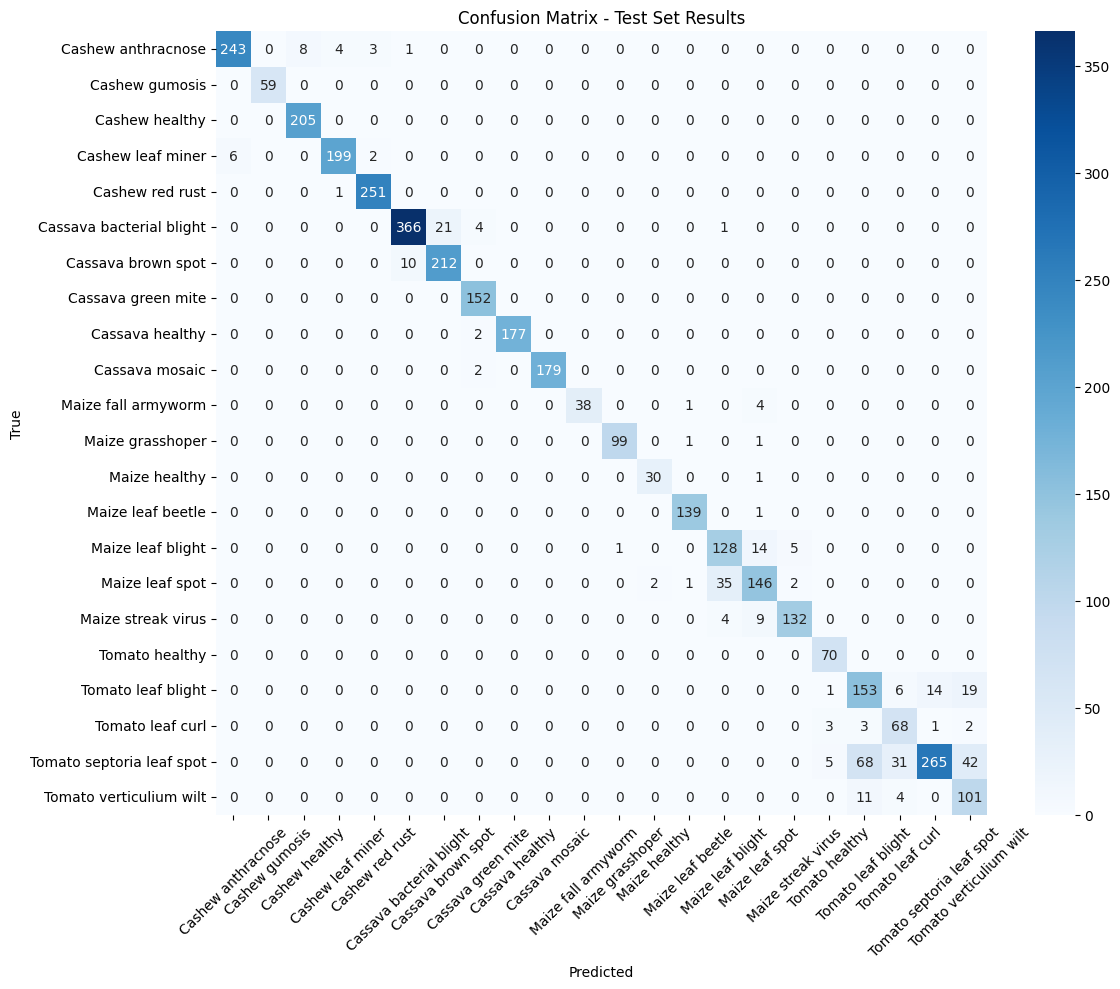


🏁 TEST EVALUATION SUMMARY
🤖 Model: efficientnet_b3_saved
🎯 Test Accuracy: 90.53%
📊 Total Test Samples: 3769
🏷️  Number of Classes: 22
💾 Results saved to: models
🎯 Saved model test accuracy: 90.53%


In [23]:
# Load saved model and evaluate
model_path = "models/best_model_efficientnet_b3_amp.pth"
saved_model = model_setup.create_model(len(train_dataset.classes), 'efficientnet_b3')
saved_model.load_state_dict(torch.load(model_path)['model_state_dict'])
saved_model = saved_model.to(device)

# Evaluate it
test_results = evaluation.comprehensive_test_evaluation(
    saved_model, test_loader, device, train_dataset.classes, 
    model_name='efficientnet_b3_saved', use_amp=True
)
print(f"🎯 Saved model test accuracy: {test_results['test_accuracy']:.2f}%")

In [11]:
import os
import psutil

# Check CPU cores
print(f"💻 CPU Info:")
print(f"   Physical cores: {psutil.cpu_count(logical=False)}")
print(f"   Logical cores: {psutil.cpu_count(logical=True)}")
print(f"   Current workers: {os.cpu_count()}")

# Recommended workers = min(8, cpu_cores)
recommended_workers = min(8, psutil.cpu_count(logical=True))
print(f"   Recommended workers: {recommended_workers}")

💻 CPU Info:
   Physical cores: 4
   Logical cores: 8
   Current workers: 8
   Recommended workers: 8


In [3]:
# Quick system check
import torch
import psutil

print("🖥️  System Info:")
print(f"   CPU cores: {psutil.cpu_count(logical=True)}")
print(f"   RAM: {psutil.virtual_memory().total / 1024**3:.1f} GB")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name()}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("   GPU: Not available")

🖥️  System Info:
   CPU cores: 8
   RAM: 30.9 GB
   GPU: Tesla T4
   GPU Memory: 14.7 GB


In [12]:
def inspect_checkpoint(path):
    import torch
    checkpoint = torch.load(path, map_location='cpu')
    for k, v in checkpoint.items():
        if isinstance(v, (int, float, str, tuple, list)):
            print(f"{k}: {v}")
        else:
            print(f"{k}: <{type(v)}>")


In [19]:

inspect_checkpoint('models/best_efficientnet_b3_320x320px_acc88.8_20250624_130140.pth')
inspect_checkpoint('models/best_model_efficientnet_b3_amp.pth')

epoch: 7
model_state_dict: <<class 'collections.OrderedDict'>>
optimizer_state_dict: <<class 'dict'>>
train_loss: 0.25785661333663895
val_loss: 0.34118925694818214
val_acc: 88.829928362961
timestamp: 2025-06-24T13:13:17.445599
image_size: (320, 320)
batch_size: 256
num_workers: 8
optimizer_name: adamw
optimizer_params: <<class 'dict'>>
scheduler_name: plateau
scheduler_params: <<class 'dict'>>
config_dict: <<class 'dict'>>
class_names: ['Cashew anthracnose', 'Cashew gumosis', 'Cashew healthy', 'Cashew leaf miner', 'Cashew red rust', 'Cassava bacterial blight', 'Cassava brown spot', 'Cassava green mite', 'Cassava healthy', 'Cassava mosaic', 'Maize fall armyworm', 'Maize grasshoper', 'Maize healthy', 'Maize leaf beetle', 'Maize leaf blight', 'Maize leaf spot', 'Maize streak virus', 'Tomato healthy', 'Tomato leaf blight', 'Tomato leaf curl', 'Tomato septoria leaf spot', 'Tomato verticulium wilt']
class_to_idx: <<class 'dict'>>
epoch: 7
model_state_dict: <<class 'collections.OrderedDict'>>

In [ ]:
# =============================================================================
# STEP 1: Clean and save dataset (run once per dataset)
# =============================================================================

# NEW: Enhanced cleaning with relative paths (recommended for portability)
clean_paths, clean_labels = dataset_cleaner.clean_and_save_dataset(
    data_dir='/home/user/datasets/crop_pest_data',  # Your new data path
    save_path='clean_dataset.pkl',
    max_workers=None,  # Auto-detect optimal CPU cores
    use_relative_paths=True  # NEW: Saves relative paths for portability
)



# =============================================================================
# ALTERNATIVE: If you have a pickle file from another instance
# =============================================================================

# If you have a clean_dataset.pkl from the original instance, you can still use it:
# train_paths, train_labels, val_paths, val_labels, test_paths, test_labels = data_splitter.split_clean_dataset(
#     pickle_path='clean_dataset.pkl',  # The pickle file from original instance
#     base_data_dir='/home/user/datasets/crop_pest_data'  # Your new data path
# )

# Option 2: Load and evaluate the best checkpoint from training
# checkpoint = torch.load(results['best_model_path'])
# model.load_state_dict(checkpoint['model_state_dict'])
# test_results = evaluation.comprehensive_test_evaluation(
#     model, test_loader, device, train_dataset.classes, 
#     model_name=config.MODEL_NAME + "_best", use_amp=True
# )
# print(f"🎯 Test accuracy (best weights): {test_results['test_accuracy']:.2f}%")

In [33]:
# =============================================================================
# RELOAD MODULES AFTER FIXING SCHEDULER ISSUE
# =============================================================================

import importlib
importlib.reload(training)

print("✅ Training module reloaded with scheduler fix!")
print("🔧 Fixed: Different scheduler types now handled correctly")
print("   - ReduceLROnPlateau: scheduler.step(val_loss)")  
print("   - Other types (Cosine, Sequential, etc.): scheduler.step()")


✅ Training module reloaded with scheduler fix!
🔧 Fixed: Different scheduler types now handled correctly
   - ReduceLROnPlateau: scheduler.step(val_loss)
   - Other types (Cosine, Sequential, etc.): scheduler.step()


In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"torch.compile available: {hasattr(torch, 'compile')}")

PyTorch version: 2.7.0+cu128
CUDA available: False
torch.compile available: True
